<a href="https://colab.research.google.com/github/Koks-creator/LeafsAnalyzeWithYoloSegmentation/blob/main/yolov11_seg_leaf_disease_giten.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO11 — Instance Segmentation


## 1. Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive

Mounted at /content/gdrive


## 2. Setup and imports

In [ ]:
!pip install -q ultralytics==8.4.19 sahi==0.11.34 roboflow pycocotools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.0 MB/s eta 0:00:00


In [ ]:
!pip freeze | grep -e ultralytics -e sahi -e torch -e roboflow

roboflow==1.4.1
sahi==0.11.34
torch==2.11.0+cu128
torchao==0.10.0
torchaudio==2.11.0+cu128
torchcodec==0.11.0+cu128
torchdata==0.11.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision==0.26.0+cu128
ultralytics==8.4.19
ultralytics-thop==2.1.6


In [ ]:
import os, glob, shutil, yaml, random
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import json
from collections import defaultdict

from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
MODEL_DIR = "./models"
MODEL_NAME = "yolo11s-seg.pt"     # n/s/m/l/x-seg
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

IMGSZ = 640
BATCH_SIZE = 8 # -1 = autobatch
WORKERS = 2
EPOCHS = 60
RUN_NAME = "yolo11m_seg_lesion"
PROJECT = "/mydrive/yoloTrain/runs"


# 3. Downloading dataset
Dataset must be **Instance Segmentation** type. Here I use leaf-disease-segmentation-yguau which is SEMANTIC segmentation type (no yolo format, that's why I had to do weird shit to make it work :p)

In [ ]:
use_local = False
resume = False

In [ ]:
CLASS_NAMES = ["lesion"]

if use_local:
    DATASET_PATH = "/content/train_data"
    CONFIG_YAML_FILE = "./config/data.yaml"

    !unzip -q /mydrive/yoloTrain/train_data.zip -d /content

    data_yaml = {
        'path' : DATASET_PATH,
        'train': 'images/train',
        'val'  : 'images/val',
        'test' : 'images/test',
        'names': {i: n for i, n in enumerate(CLASS_NAMES)},
    }
    os.makedirs("config", exist_ok=True)
    with open(CONFIG_YAML_FILE, 'w') as f:
        yaml.dump(data_yaml, f, sort_keys=False, allow_unicode=True)

else:
    RAW = Path("/content/ds/lesion_raw")
    OUT = Path("/content/ds/lesion_yolo")

    rf = Roboflow(api_key="")
    project = rf.workspace("xfhor-guq8a").project("leaf-disease-segmentation-yguau")
    ver = max(v.version if isinstance(v.version, int) else int(str(v.version).split("/")[-1])
              for v in project.versions())

    if not RAW.exists():
        project.version(ver).download("coco-segmentation", location=str(RAW))

    # listing
    for p in sorted(RAW.rglob("*")):
        if p.is_dir():
            n = len([f for f in p.glob("*") if f.suffix.lower() in (".jpg", ".jpeg", ".png")])
            print(f"[DIR ] {p.relative_to(RAW)}/   ({n} obrazow)")
        elif p.suffix == ".json":
            print(f"[JSON] {p.relative_to(RAW)}   ({p.stat().st_size/1024:.0f} KB)")

    jsons = sorted(RAW.rglob("*.json"))
    assert jsons, "No json files sar"

    #COCO -> Polygons (supports ORA and RLE polygon lists)
    def anns_to_polygons(ann, h, w, min_area=15, eps_frac=0.002):
        seg = ann.get("segmentation")
        out = []
        if isinstance(seg, list) and seg and isinstance(seg[0], (list, tuple)):
            for s in seg:
                if len(s) >= 6:
                    out.append(np.asarray(s, dtype=float).reshape(-1, 2))
            return out
        if isinstance(seg, dict):                       # RLE
            from pycocotools import mask as maskutils
            rle = seg
            if isinstance(rle.get("counts"), list):
                rle = maskutils.frPyObjects(rle, h, w)
            m = maskutils.decode(rle)
            if m.ndim == 3:
                m = m.max(axis=2)
            cnts, _ = cv2.findContours(m.astype(np.uint8),
                                       cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in cnts:
                if cv2.contourArea(c) < min_area:
                    continue
                c = cv2.approxPolyDP(c, eps_frac * cv2.arcLength(c, True), True).reshape(-1, 2)
                if len(c) >= 3:
                    out.append(c.astype(float))
        return out

    def split_name(jp):
        for p in (jp.parent.name.lower(), jp.stem.lower()):
            for key, val in (("train","train"), ("valid","valid"), ("val","valid"), ("test","test")):
                if key in p:
                    return val
        return "train"

    if OUT.exists():
        shutil.rmtree(OUT)

    cat_names = {}
    stats = defaultdict(lambda: [0, 0, 0])

    for jp in jsons:
        sp   = split_name(jp)
        data = json.loads(jp.read_text())
        if "annotations" not in data or "images" not in data:
            continue

        for c in data.get("categories", []):
            if c["id"] != 0 or c.get("supercategory") not in (None, "none"):
                cat_names[c["id"]] = c["name"]

        by_img = defaultdict(list)
        for a in data["annotations"]:
            by_img[a["image_id"]].append(a)

        img_dir = OUT / sp / "images"; img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir = OUT / sp / "labels"; lbl_dir.mkdir(parents=True, exist_ok=True)

        for im in data["images"]:
            s = jp.parent / im["file_name"]
            if not s.exists():
                hit = list(RAW.rglob(im["file_name"]))
                if not hit:
                    continue
                s = hit[0]

            h, w  = im["height"], im["width"]
            lines = []
            for a in by_img.get(im["id"], []):
                for poly in anns_to_polygons(a, h, w):
                    poly[:, 0] = np.clip(poly[:, 0] / w, 0, 1)
                    poly[:, 1] = np.clip(poly[:, 1] / h, 0, 1)
                    lines.append(f"{a['category_id']} " +
                                 " ".join(f"{x:.6f} {y:.6f}" for x, y in poly))

            shutil.copy(s, img_dir / s.name)
            (lbl_dir / f"{Path(s.name).stem}.txt").write_text("\n".join(lines))
            stats[sp][0] += 1; stats[sp][1] += len(lines); stats[sp][2] += (len(lines) == 0)

    print()
    for sp, (ni, na, ne) in stats.items():
        print(f"{sp:6} images={ni:5}  instances={na:6}  no labels={ne}")

    # Remap class IDs to 0..n-1 (Roboflow starts at 1)
    used = {int(l.split()[0]) for f in OUT.rglob("*.txt")
            for l in f.read_text().splitlines() if l.strip()}
    remap = {old: new for new, old in enumerate(sorted(used))}
    CLASS_NAMES_MAP = {new: cat_names.get(old, f"class{old}") for old, new in remap.items()}

    if any(k != v for k, v in remap.items()):
        for f in OUT.rglob("*.txt"):
            out = []
            for l in f.read_text().splitlines():
                if l.strip():
                    p = l.split()
                    out.append(" ".join([str(remap[int(p[0])])] + p[1:]))
            f.write_text("\n".join(out))

    cfg = {
        "path" : str(OUT.resolve()),
        "train": "train/images",
        "val"  : "valid/images" if (OUT / "valid").exists() else "train/images",
        "names": CLASS_NAMES_MAP or {0: "lesion"},
    }
    cfg["test"] = "test/images" if (OUT / "test").exists() else cfg["val"]

    DATASET_PATH     = str(OUT)
    CONFIG_YAML_FILE = str(OUT / "data.yaml")
    Path(CONFIG_YAML_FILE).write_text(yaml.dump(cfg, sort_keys=False, allow_unicode=True))

print()
print(open(CONFIG_YAML_FILE).read())

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ds/lesion_raw in coco-segmentation:: 100%|██████████| 1476/1476 [00:00<00:00, 4002.26it/s]


[DIR ] test/   (31 obrazow)
[JSON] test/_annotations.coco.json   (84 KB)
[DIR ] train/   (1320 obrazow)
[JSON] train/_annotations.coco.json   (3815 KB)
[DIR ] valid/   (117 obrazow)
[JSON] valid/_annotations.coco.json   (380 KB)

test   obrazow=   31  instancji=   306  bez etykiet=0
train  obrazow= 1320  instancji= 11128  bez etykiet=3
valid  obrazow=  117  instancji=  1549  bez etykiet=0

path: /content/ds/lesion_yolo
train: train/images
val: valid/images
names:
  0: Leaf Diseases
test: test/images



In [ ]:
import re, os, glob
root = '/content/ds/lesion_yolo'
base = lambda p: re.split(r'[._]rf[._]', os.path.basename(p))[0]
S = {s: {base(p) for p in glob.glob(f'{root}/{s}/images/*')} for s in ['train','valid','test']}
print({s: (len(glob.glob(f"{root}/{s}/images/*")), len(v)) for s, v in S.items()})
print('train∩valid:', len(S['train'] & S['valid']), '| train∩test:', len(S['train'] & S['test']))

{'train': (1320, 440), 'valid': (117, 117), 'test': (31, 31)}
train∩valid: 0 | train∩test: 0


### 4a. Sanity-check of labels



In [ ]:
def check_labels(root, split="train", n_show=3):
    lbl_dir = os.path.join(root, split, "labels")
    if not os.path.isdir(lbl_dir):
        lbl_dir = os.path.join(root, "labels", split)
    files = sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))
    assert files, f"no labels i chuj in {lbl_dir}"

    tok_counts, n_inst, empties = [], 0, 0
    for f in files:
        lines = [l for l in open(f).read().splitlines() if l.strip()]
        if not lines:
            empties += 1
        for l in lines:
            tok_counts.append(len(l.split()))
            n_inst += 1

    tok = np.array(tok_counts)
    print(f"[{split}] files: {len(files)} | instances: {n_inst} | empty files: {empties}")
    print(f"[{split}] tokens in line: min={tok.min()} median={int(np.median(tok))} max={tok.max()}")

    if (tok == 5).all(): # class id, x1, y2, w, h
        print("5 TOKEN, IT'S REGULAR DETECTION SHIT")
    elif (tok >= 7).all() and (tok % 2 == 1).all():
        print("OK")
    else:
        print("SOME WEIRD, MIX SHIT")

    print("Let's see:")
    for f in files[:n_show]:
        line = open(f).readline().strip()
        print(f"  {os.path.basename(f)}: {line[:110]}{'...' if len(line) > 110 else ''}")

check_labels(DATASET_PATH, "train")

[train] plików: 1320 | instancji: 11128 | pustych plików: 3
[train] tokenów w linii: min=9 mediana=17 max=533
OK — wielokąty.

Przykład:
  00000_png.rf.12832ae7d09004ee161b9387f9f8bc5e.txt: 0 0.503067 0.817022 0.506134 0.834042 0.518405 0.838298 0.512270 0.817022 0.503067 0.817022
  00000_png.rf.4104369096562528a202cc660141406f.txt: 0 0.598958 0.871320 0.589953 0.848991 0.580073 0.850030 0.585302 0.868100 0.598958 0.871320
  00000_png.rf.4c0894b822346438d7bac5f27fc0b278.txt: 0 0.535311 0.913814 0.527283 0.890617 0.517094 0.891152 0.521478 0.909816 0.535311 0.913814


### 4b. Preview


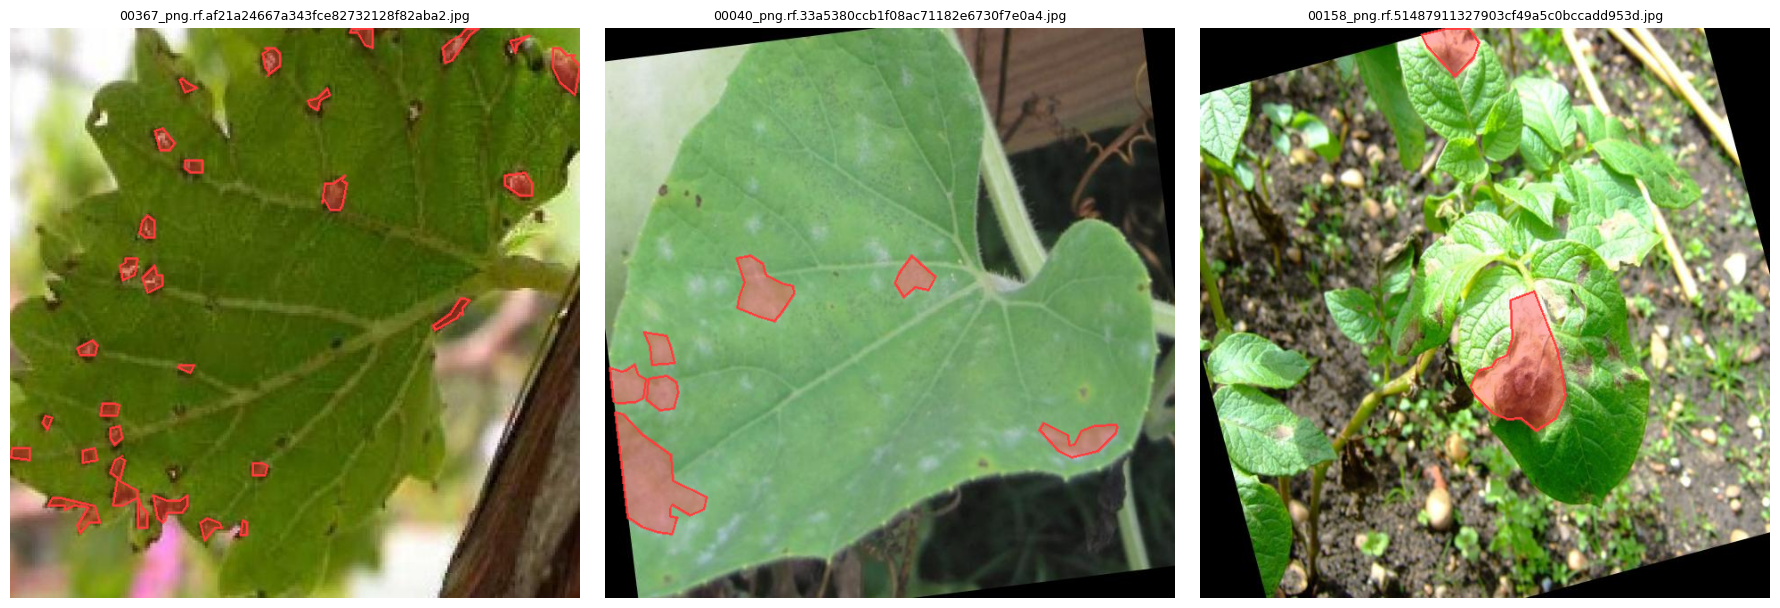

In [ ]:
def preview_gt(root, split="train", n=3, seed=0):
    img_dir = os.path.join(root, split, "images")
    if not os.path.isdir(img_dir):
        img_dir = os.path.join(root, "images", split)
    lbl_dir = img_dir.replace("images", "labels")

    imgs = sorted(glob.glob(os.path.join(img_dir, "*")))
    random.Random(seed).shuffle(imgs)
    imgs = imgs[:n]

    fig, axes = plt.subplots(1, len(imgs), figsize=(6 * len(imgs), 6))
    axes = np.atleast_1d(axes)

    for ax, ip in zip(axes, imgs):
        img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lp = os.path.join(lbl_dir, Path(ip).stem + ".txt")

        overlay = img.copy()
        if os.path.exists(lp):
            for line in open(lp).read().splitlines():
                p = line.split()
                if len(p) < 7:
                    continue
                cls = int(p[0])
                pts = np.array(p[1:], dtype=float).reshape(-1, 2) * [w, h]
                color = [(255, 60, 60), (60, 255, 120), (80, 160, 255),
                         (255, 200, 60), (200, 80, 255)][cls % 5]
                cv2.fillPoly(overlay, [pts.astype(np.int32)], color)
                cv2.polylines(img, [pts.astype(np.int32)], True, color, 2)

        ax.imshow(cv2.addWeighted(overlay, 0.4, img, 0.6, 0))
        ax.set_title(Path(ip).name, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

preview_gt(DATASET_PATH, "train")

## 5. GPU

In [ ]:
if torch.cuda.is_available():
    device = 0
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = "cpu"
    print("Damn, no GPU — CPU.")

GPU: Tesla T4
VRAM: 15.6 GB


## 6. Model

In [ ]:
os.makedirs(MODEL_DIR, exist_ok=True)

if resume:
    MODEL_PATH = f"{PROJECT}/{RUN_NAME}/weights/last.pt"
elif not os.path.exists(MODEL_PATH):
    YOLO(MODEL_NAME)
    if os.path.exists(MODEL_NAME):
        shutil.move(MODEL_NAME, MODEL_PATH)

model = YOLO(MODEL_PATH)
print("Wagi:", MODEL_PATH)
print("task:", model.task)
assert model.task == "segment", "No segment weights!!11!!11"

Wagi: ./models/yolo11s-seg.pt
task: segment


Training

In [ ]:
if not resume:
    results = model.train(
        data=CONFIG_YAML_FILE,
        epochs=EPOCHS,
        patience=40,
        imgsz=IMGSZ,
        batch=BATCH_SIZE,
        cache="ram",
        overlap_mask=True,
        mask_ratio=4,
        copy_paste=0.3,
        copy_paste_mode="flip",
        optimizer="AdamW",
        lr0=0.001,
        lrf=0.01,
        cos_lr=True,
        warmup_epochs=5,
        weight_decay=0.0005,
        degrees=10.0,
        scale=0.5,
        shear=2.0,
        perspective=0.0005,
        translate=0.1,
        fliplr=0.5,
        flipud=0.0,
        mosaic=1.0,
        close_mosaic=15,
        mixup=0.0,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        box=7.5,
        cls=0.5,
        dfl=1.5,
        seed=0,
        plots=True,
        project=PROJECT,
        name=RUN_NAME,
        save=True, save_period=25,
        device=device, workers=WORKERS,
        amp=True, verbose=True,
    )
else:
    results = model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.132 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/ds/lesion_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./models/yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

In [ ]:
BEST = f"{PROJECT}/{RUN_NAME}/weights/best.pt"
print(BEST, "->", os.path.exists(BEST))

/mydrive/yoloTrain/runs/yolo11s_seg_lesion/weights/best.pt -> True


## 8. Validation

The segmentation model returns **two sets of metrics**. `metrics.box.*` describes the quality
of the boxes, and in the `-seg` model, it still exists—it’s easy to mistakenly report it
as a segmentation result. What matters is `metrics.seg.*`.

A large discrepancy between them is diagnostic: a high `box mAP` with a low
`seg mAP` means that the model finds objects but outlines them poorly—usually due to too low
a mask resolution (`mask_ratio` / `imgsz`).

Translated with DeepL.com (free version)

In [ ]:
model = YOLO(BEST)
metrics = model.val(
    data=CONFIG_YAML_FILE,
    split="test",
    imgsz=IMGSZ,
    conf=0.001,
    iou=0.6,
    plots=True,
)

print(f"BOX   mAP50-95: {metrics.box.map:.4f} | mAP50: {metrics.box.map50:.4f}")
print(f"MASK  mAP50-95: {metrics.seg.map:.4f} | mAP50: {metrics.seg.map50:.4f}")
print(f"delta (box - mask) mAP50-95: {metrics.box.map - metrics.seg.map:+.4f}")

Ultralytics 8.4.19 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 32.6±19.2 MB/s, size: 50.6 KB)
val: Scanning /content/ds/lesion_yolo/test/labels... 31 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 31/31 506.0it/s 0.1s
val: New cache created: /content/ds/lesion_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.1s
                   all         31        306      0.644      0.556       0.56      0.274      0.649      0.526      0.525      0.227
Speed: 7.4ms preprocess, 21.8ms inference, 0.0ms loss, 6.8ms postprocess per image
Results saved to /content/runs/segment/val
BOX   mAP50-95: 0.2736 | mAP50: 0.5604
MASK  mAP50-95: 0.2270 | mAP50: 0.5246
delta (box - mask) mAP50-95: +0.0466


In [ ]:
rows = []
for i, c in enumerate(metrics.seg.ap_class_index):
    rows.append({
        "class"    : model.names[c],
        "P_mask"   : round(float(metrics.seg.p[i]), 4),
        "R_mask"   : round(float(metrics.seg.r[i]), 4),
        "AP50_mask": round(float(metrics.seg.ap50[i]), 4),
        "AP50_box" : round(float(metrics.box.ap50[i]), 4),
    })

pd.DataFrame(rows).sort_values("AP50_mask")

,class,P_mask,R_mask,AP50_mask,AP50_box
0,Leaf Diseases,0.6494,0.5261,0.5246,0.5604


## 9. Prediction

`retina_masks=True` - that's important, without it masks are in model's input resolution instead of original img resolution.

Zdjęć testowych: 31
orig_shape : (640, 640)
maski      : (4, 640, 640)
instancji  : 4


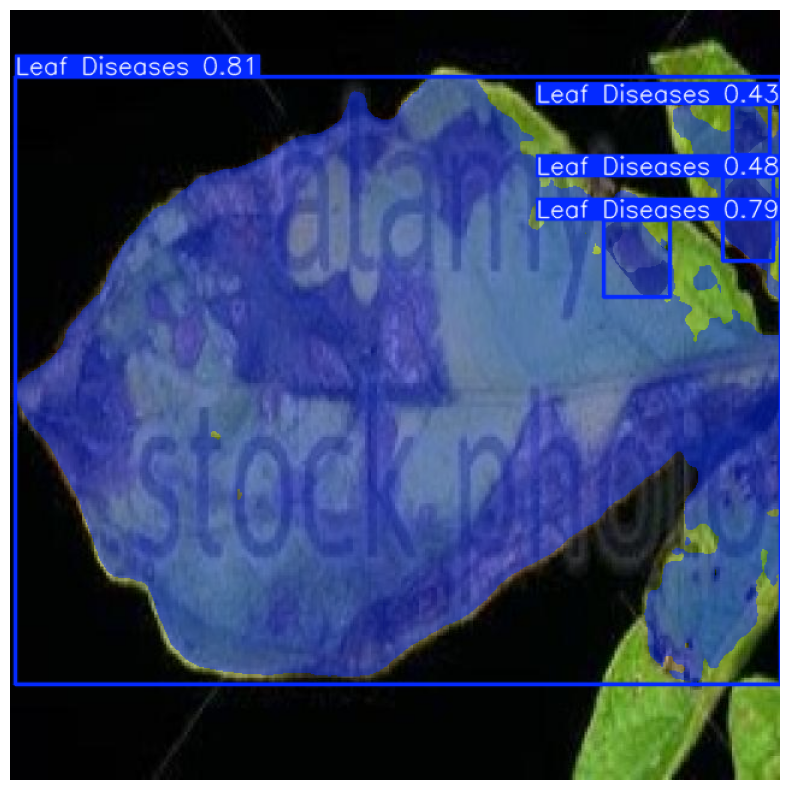

In [ ]:
conf = 0.4
iou_nms = 0.7

test_imgs = sorted(glob.glob(os.path.join(DATASET_PATH, "test", "images", "*")))
if not test_imgs:
    test_imgs = sorted(glob.glob(os.path.join(DATASET_PATH, "valid", "images", "*")))
print(f"Zdjęć testowych: {len(test_imgs)}")

res = model.predict(test_imgs[0], retina_masks=True, conf=conf, iou=iou_nms, verbose=False)[0]

print("orig_shape :", res.orig_shape)
print("maski      :", tuple(res.masks.data.shape) if res.masks is not None else "brak")
print("instancji  :", 0 if res.masks is None else len(res.masks))

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
plt.axis("off"); plt.show()

## 10. Area Measurement

This is where the fun begins, here we're actually calcuating area

I calculate `area_pct` based on the dimensions of the mask itself, not the original—this ensures that the result
is correct regardless of whether `retina_masks` worked. I convert `area_px`
back to the original scale.

**px→mm calibration:** You need an object of known dimensions in the frame (a ruler,
a coin, a calibration marker). Measure its length in pixels and divide it by
its actual length. The calibration is only valid for a fixed acquisition geometry—
changing the camera distance invalidates it.

In [ ]:
PX_PER_MM = None      # np. 12.5  (pikseli na milimetr); None = tylko piksele i %

def measure(results_iter, names, px_per_mm=None):
    rows = []
    for r in results_iter:
        h, w = r.orig_shape
        img  = Path(r.path).name

        if r.masks is None or len(r.masks) == 0:
            rows.append({"image": img, "inst_id": None, "class": None, "conf": None,
                         "area_pct": 0.0, "area_px": 0, "area_mm2": None})
            continue

        m       = r.masks.data.bool().cpu()
        mh, mw  = m.shape[-2:]
        denom   = mh * mw

        for i in range(len(m)):
            pct = 100.0 * m[i].sum().item() / denom
            px  = int(round(pct / 100.0 * h * w))
            rows.append({
                "image"   : img,
                "inst_id" : i,
                "class"   : names[int(r.boxes.cls[i])],
                "conf"    : round(float(r.boxes.conf[i]), 3),
                "area_pct": round(pct, 4),
                "area_px" : px,
                "area_mm2": round(px / px_per_mm**2, 3) if px_per_mm else None,
            })
    return pd.DataFrame(rows)

stream = model.predict(source=test_imgs, stream=True, retina_masks=True,
                       conf=CONF, iou=IOU_NMS, verbose=False)

df = measure(stream, model.names, PX_PER_MM)
df.head(20)

## Cheat Sheet — Segmentation-Specific Arguments

| Argument | Default | Range | When to Use |
|---|---|---|---|
| `overlap_mask` | `True` | bool | `False` only for transparent, overlapping objects |
| `mask_ratio` | `4` | 1–8 | `2` for thin structures; `8` when speed matters and objects are large |
| `copy_paste` | `0.0` | 0–1 | 0.2–0.4 for sparse classes; 0.5–0.7 for severe class imbalance |
| `copy_paste_mode` | `flip` | flip / mixup | `mixup` when visual diversity is more important than position |
| `retina_masks` *(predict)* | `False` | bool | `True` whenever you measure area |

**Post-training diagnostics**

| Symptom | Probable cause |
|---|---|
| `seg mAP` ≈ `box mAP`, rectangular masks | you’re training on detection labels |
| `box mAP` high, `seg mAP` low | mask resolution too low — `mask_ratio=2` or larger `imgsz` |
| jagged mask edges | same as above + consider using `yolo11m-seg` instead of `s` |
| good `val`, poor on production | augmentation does not cover real-world acquisition conditions |
| CUDA OOM with the same `imgsz` as detection | normal — reduce the batch size or set `batch=-1` |